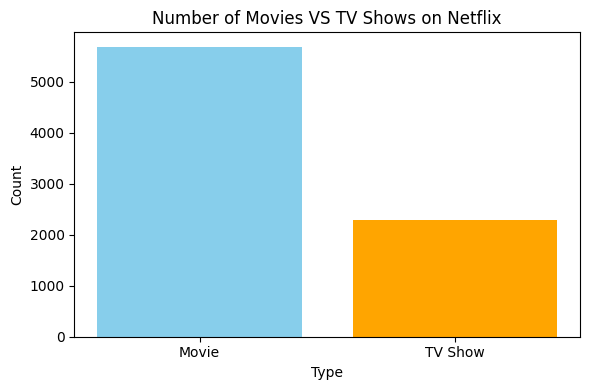

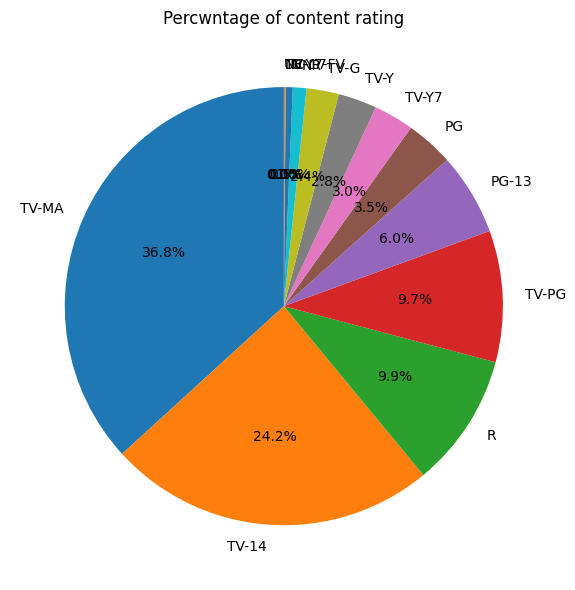

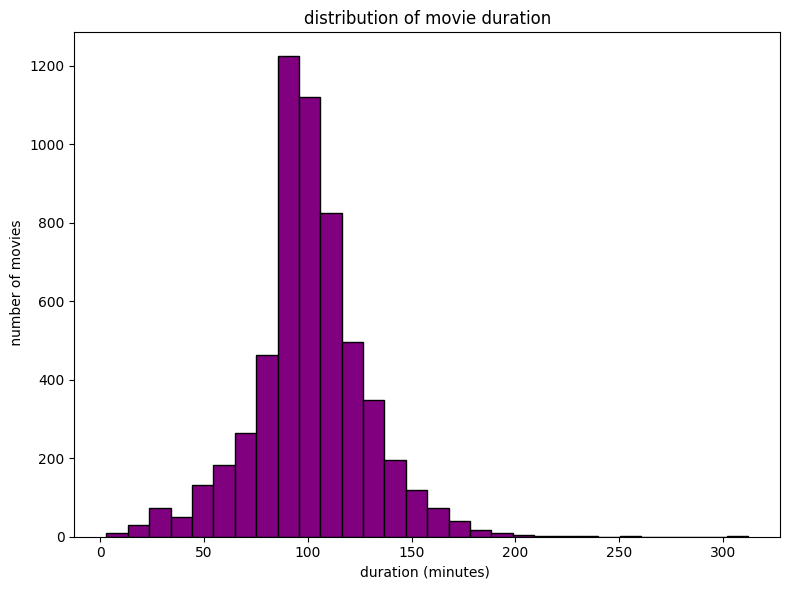

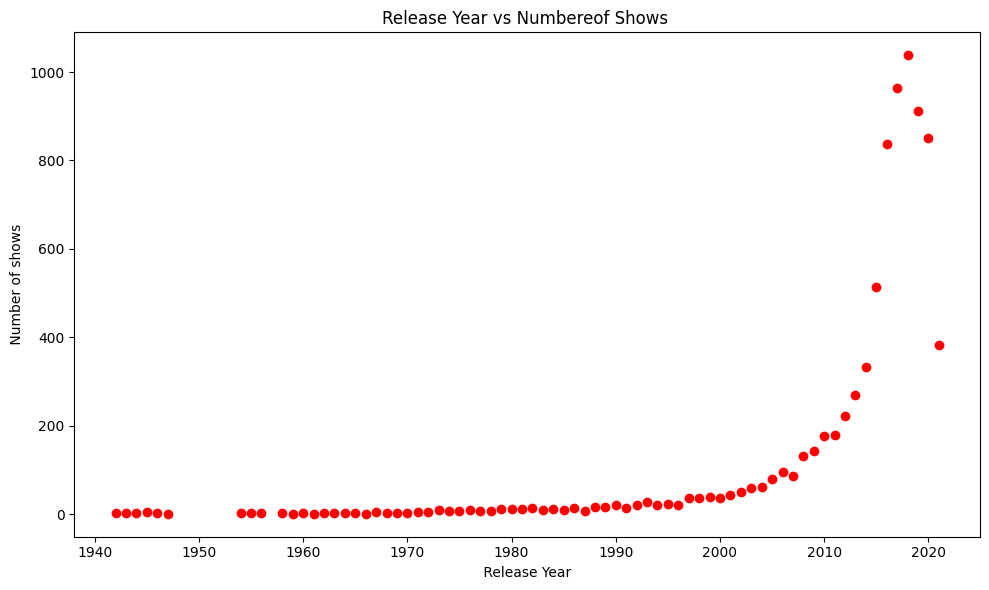

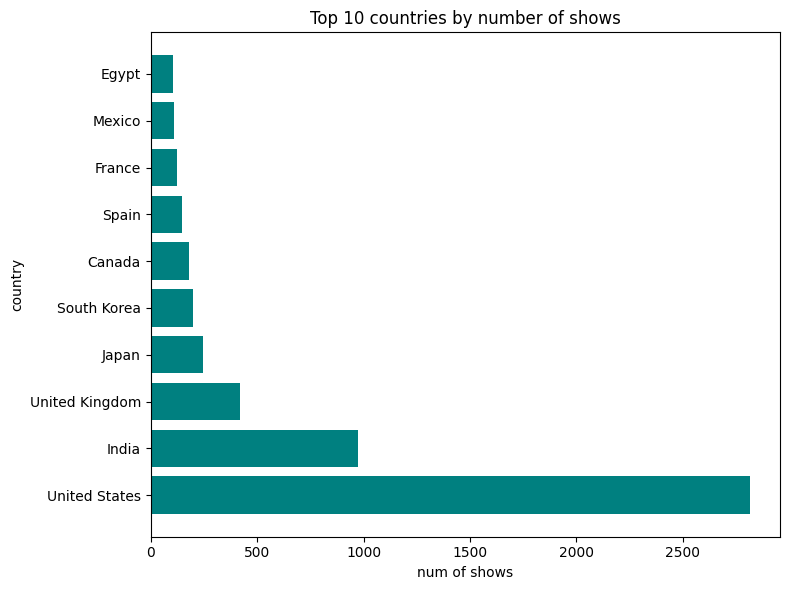

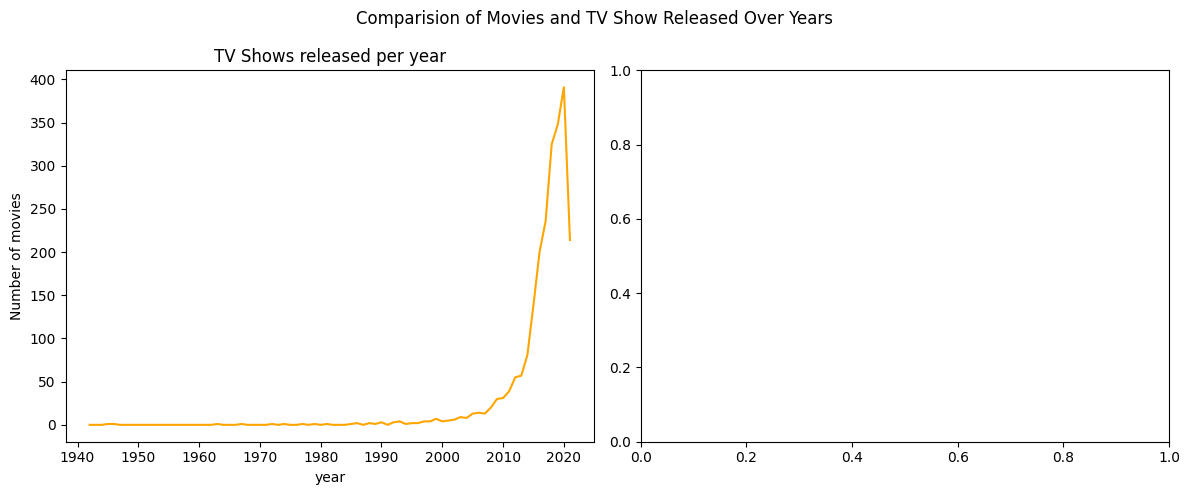

In [28]:
# s-1 import the libraries
import pandas as pd 
import matplotlib.pyplot as plt

# load the data 
df = pd.read_csv('netflix_titles.csv')

# clean data 
df = df.dropna(subset=['type' , 'release_year' , 'rating' , 'country' , 'duration'])

type_counts = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index , type_counts.values , color=['skyblue' , 'orange'] )
plt.title('Number of Movies VS TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_vs_tvShows.png')
plt.show()


rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts , labels = rating_counts.index , autopct='%1.1f%%' , startangle=90 )
plt.title('Percwntage of content rating')
plt.tight_layout()
plt.savefig('content_rating_pie.png')
plt.show()

movie_df = df[df['type'] == 'Movie'].copy()
movie_df['duration_int'] = movie_df['duration'].str.replace(' min' ,' ' ).astype(int)


plt.figure(figsize=(8,6) )
plt.hist(movie_df['duration_int'] , bins=30 , color='purple' , edgecolor= 'black')
plt.title('distribution of movie duration')
plt.xlabel('duration (minutes) ')
plt.ylabel(' number of movies')
plt.tight_layout()
plt.savefig('movie_duration_histogram.png')
plt.show()


release_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,6) )
plt.scatter(release_counts.index , release_counts.values , color='red')
           
plt.title('Release Year vs Numbereof Shows ')
plt.xlabel(' Release Year ')
plt.ylabel(' Number of shows ')
plt.tight_layout()
plt.savefig('release_year_Scatter.png')
plt.show()

country_counts = df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(country_counts.index , country_counts.values , color='teal')
plt.title('Top 10 countries by number of shows')
plt.xlabel('num of shows')
plt.ylabel('country')
plt.tight_layout()
plt.savefig('top_10countries.png')
plt.show()

content_by_year = df.groupby(['release_year', 'type']).size().unstack().fillna(0)
fig, ax = plt.subplots(1,2, figsize =(12,5))

# first subplot:movies

ax[0].plot(content_by_year.index , content_by_year['TV Show'] , color='orange')
ax[0].set_title('TV Shows released per year')
ax[0].set_xlabel('year')
ax[0].set_ylabel('Number of movies')        

fig.suptitle('Comparision of Movies and TV Show Released Over Years')

plt.tight_layout()
plt.savefig('movies_TV_Shows_comparision.png')
plt.show()